##### Ideal QSVM (SVC Precomputed Kernel) - Spambase

In [11]:
import qiskit, qiskit_aer, qiskit_machine_learning
print("Qiskit:", qiskit.__version__)
print("Aer:", qiskit_aer.__version__)
print("QML:", qiskit_machine_learning.__version__)

Qiskit: 2.2.3
Aer: 0.17.2
QML: 0.9.0


In [12]:
# --- Import Libraries ---
import pandas as pd
import os
import numpy as np
import time
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif, VarianceThreshold
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, recall_score, balanced_accuracy_score, precision_score, f1_score

In [13]:
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

In [14]:
# --- Qiskit Imports ---
from qiskit.circuit.library import ZZFeatureMap
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC, PegasosQSVC

##### Load Dataset

In [15]:
# --- Import Spambase Column Names ---
spambase_columns = [
    "word_freq_make",
    "word_freq_address",
    "word_freq_all",
    "word_freq_3d",
    "word_freq_our",
    "word_freq_over",
    "word_freq_remove",
    "word_freq_internet",
    "word_freq_order",
    "word_freq_mail",
    "word_freq_receive",
    "word_freq_will",
    "word_freq_people",
    "word_freq_report",
    "word_freq_addresses",
    "word_freq_free",
    "word_freq_business",
    "word_freq_email",
    "word_freq_you",
    "word_freq_credit",
    "word_freq_your",
    "word_freq_font",
    "word_freq_000",
    "word_freq_money",
    "word_freq_hp",
    "word_freq_hpl",
    "word_freq_george",
    "word_freq_650",
    "word_freq_lab",
    "word_freq_labs",
    "word_freq_telnet",
    "word_freq_857",
    "word_freq_data",
    "word_freq_415",
    "word_freq_85",
    "word_freq_technology",
    "word_freq_1999",
    "word_freq_parts",
    "word_freq_pm",
    "word_freq_direct",
    "word_freq_cs",
    "word_freq_meeting",
    "word_freq_original",
    "word_freq_project",
    "word_freq_re",
    "word_freq_edu",
    "word_freq_table",
    "word_freq_conference",
    "char_freq_;",
    "char_freq_(",
    "char_freq_[",
    "char_freq_!",
    "char_freq_$",
    "char_freq_#",
    "capital_run_length_average",
    "capital_run_length_longest",
    "capital_run_length_total",
    "label"
]

# --- 1. Load the Spambase Dataset (LOCAL PATH) ---
# file_path = '/kaggle/input/spambase/spambase.data'
file_path = r'C:\Users\User\Documents\MyProjects\FYP_ResearchProject\data\spambase\spambase.data'
df = pd.read_csv(file_path, header=None, names=spambase_columns)
df.drop_duplicates(inplace=True)

print(f"Dataset loaded: {df.shape[0]} samples, {df.shape[1]} features")

Dataset loaded: 4210 samples, 58 features


##### Experiment Configurations

In [16]:
# ==========================================
# EXPERIMENT CONFIGURATIONS
# ==========================================

experiments = [
    # EXP 1: Shot Noise Effect
    {'id': 'Exp1_128shots', 'samples': 300, 'k_features': 3, 'shots': 128, 'reps': 1, 'entanglement': 'linear'},
    {'id': 'Exp1_512shots', 'samples': 300, 'k_features': 3, 'shots': 512, 'reps': 1, 'entanglement': 'linear'},
    {'id': 'Exp1_1024shots', 'samples': 300, 'k_features': 3, 'shots': 1024, 'reps': 1, 'entanglement': 'linear'},
    
    # EXP 2: Reps Effect
    {'id': 'Exp2_Reps1', 'samples': 300, 'k_features': 3, 'shots': 1024, 'reps': 1, 'entanglement': 'linear'},
    {'id': 'Exp2_Reps2', 'samples': 300, 'k_features': 3, 'shots': 1024, 'reps': 2, 'entanglement': 'linear'},
    
    # EXP 3: Entanglement
    {'id': 'Exp3_Circular', 'samples': 300, 'k_features': 3, 'shots': 1024, 'reps': 1, 'entanglement': 'circular'},
    {'id': 'Exp3_Full', 'samples': 300, 'k_features': 3, 'shots': 1024, 'reps': 1, 'entanglement': 'full'},
]


print(f"Total experiments configured: {len(experiments)}")
print("Running might take hours or even several days")

Total experiments configured: 7
Running might take hours or even several days


##### Main Experiment

In [17]:
# ==========================================
# MAIN EXPERIMENT LOOP
# ==========================================

# Store all results
all_results = []

# Split features and target once
X = df.drop('label', axis=1)
y = df['label']

for exp_num, config in enumerate(experiments, 1):
    print("\n" + "=" * 80)
    print(f"EXPERIMENT {exp_num}/{len(experiments)}: {config['id']}")
    print("=" * 80)
    print(f"  Samples: {config['samples']}")
    print(f"  K Features: {config['k_features']}")
    print(f"  Shots: {config['shots']}")
    print(f"  Reps: {config['reps']}")
    print(f"  Entanglement: {config['entanglement']}")
    print("=" * 80)

    # ===================================================================
    # 1. CREATE DATASET BASED ON SAMPLE SIZE
    # ===================================================================

    train_samples = config['samples']
    subset_size = int(round(train_samples / 0.7))

    # First sample subset from full dataset
    X_subset, _, y_subset, _ = train_test_split(
        X, y,
        train_size=subset_size,
        stratify=y,
        random_state=42
    )

    # Then do 70:30 split
    X_train, X_test, y_train, y_test = train_test_split(
        X_subset, y_subset,
        test_size=0.30,
        random_state=42,
        stratify=y_subset
    )

    print(f"\nDataset created: {X_train.shape[0]} train, {X_test.shape[0]} test")

    # ===================================================================
    # 2. SCALING
    # ===================================================================

    # 2. VARIANCE FILTERING & SCALING (Prevents "Invalid Value" errors)
    selector_variance = VarianceThreshold(threshold=0)
    X_train_filtered = selector_variance.fit_transform(X_train)
    X_test_filtered = selector_variance.transform(X_test)
    remaining_cols = X_train.columns[selector_variance.get_support()]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_filtered)
    X_test_scaled = scaler.transform(X_test_filtered)
    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=remaining_cols)
    X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=remaining_cols)

    print("Data scaled successfully")

    # ===================================================================
    # 3. CORRELATION-BASED FEATURE DROPPING
    # ===================================================================

    THRESH = 0.9
    corr_matrix_train = X_train_scaled_df.corr().abs()
    upper_triangle = corr_matrix_train.where(
        np.triu(np.ones(corr_matrix_train.shape), k=1).astype(bool)
    )

    columns_to_drop = set()
    for column in upper_triangle.columns:
        high_corr_partners = upper_triangle.index[upper_triangle[column] > THRESH].tolist()
        if high_corr_partners:
            for partner in high_corr_partners:
                corr_main_vs_target = y_train.corr(X_train_scaled_df[column])
                corr_partner_vs_target = y_train.corr(X_train_scaled_df[partner])

                if abs(corr_main_vs_target) < abs(corr_partner_vs_target):
                    columns_to_drop.add(column)
                else:
                    columns_to_drop.add(partner)

    to_drop_final = sorted(list(columns_to_drop))
    X_train_selected = X_train_scaled_df.drop(columns=to_drop_final)
    X_test_selected = X_test_scaled_df.drop(columns=to_drop_final)

    print(f"Dropped {len(to_drop_final)} highly correlated features")

    # ===================================================================
    # 4. SELECTKBEST
    # ===================================================================

    k_features = config['k_features']
    selector = SelectKBest(score_func=mutual_info_classif, k=k_features) 
    X_train_kbest = selector.fit_transform(X_train_selected, y_train)
    X_test_kbest = selector.transform(X_test_selected)

    selected_features = X_train_selected.columns[selector.get_support()].tolist()
    print(f"SelectKBest: Selected {k_features} features:")
    for i, feat in enumerate(selected_features, 1):
      print(f"     {i}. {feat}")

    # ===================================================================
    # 5. QUANTUM KERNEL SETUP 
    # ===================================================================

    fm = ZZFeatureMap(
        feature_dimension=k_features,
        reps=config['reps'],
        entanglement=config['entanglement']
    )

    sampler = Sampler(default_shots=config['shots'])
    fidelity = ComputeUncompute(sampler=sampler)
    qkernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=fm)

    print(f"Quantum kernel configured (ZZFeatureMap, reps={config['reps']}, entanglement={config['entanglement']})")

    # ===================================================================
    # 6. COMPUTE KERNEL MATRICES
    # ===================================================================

    print("\nChecking for precomputed kernel matrices...")
    train_kernel_path = os.path.join('results_qsvm_spambase_selectKBest', f'kernel_train_{config["id"]}.npy')
    test_kernel_path = os.path.join('results_qsvm_spambase_selectKBest', f'kernel_test_{config["id"]}.npy')

    if os.path.exists(train_kernel_path) and os.path.exists(test_kernel_path):
        print(f"Loading precomputed kernels from: {train_kernel_path} and {test_kernel_path}")
        matrix_train = np.load(train_kernel_path)
        matrix_test = np.load(test_kernel_path)
        kernel_time = 0.0 # Loaded, so no time taken
    else:
        print("\nComputing kernel matrices...")
        start_kernel = time.time()

        matrix_train = qkernel.evaluate(x_vec=X_train_kbest)
        matrix_test = qkernel.evaluate(x_vec=X_test_kbest, y_vec=X_train_kbest)

        kernel_time = time.time() - start_kernel
        print(f"Kernel computation: {kernel_time:.2f}s")
        
        # Save kernel matrices
        # Ensure directory exists
        os.makedirs('results_qsvm_spambase_selectKBest', exist_ok=True)
        np.save(train_kernel_path, matrix_train)
        np.save(test_kernel_path, matrix_test)
        print(f"Saved kernel matrices to: {train_kernel_path}, {test_kernel_path}")

    # ===================================================================
    # 7. GRID SEARCH
    # ===================================================================

    print("\nUsing optimal C...")

    # Use fixed C=1.0 from classical RBF for all experiments
    best_c = 1.0
    print(f"  → Fixed C: {best_c} (from classical RBF)")

    # Train with fixed C
    start_train = time.time()
    best_model = SVC(kernel='precomputed', C=best_c, class_weight='balanced', random_state=42)
    best_model.fit(matrix_train, y_train)
    train_time = time.time() - start_train

    # For consistency, still calculate CV score
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    from sklearn.model_selection import cross_val_score
    cv_scores = cross_val_score(best_model, matrix_train, y_train, cv=cv, scoring='accuracy')
    cv_score = cv_scores.mean()

    print(f"  → CV Score: {cv_score:.4f}")
    print(f"  → Training time: {train_time:.2f}s")


    # ===================================================================
    # 8. EVALUATION
    # ===================================================================

    y_train_pred = best_model.predict(matrix_train)
    y_test_pred = best_model.predict(matrix_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_balanced_acc = balanced_accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_test, y_test_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_test_pred, pos_label=1, zero_division=0)
    gen_gap = abs(train_acc - test_acc)

    print(f"  → Train Accuracy: {train_acc:.4f}")
    print(f"  → Test Accuracy: {test_acc:.4f}")
    print(f"  → Test Balanced Accuracy: {test_balanced_acc:.4f}")
    print(f"  → Precision: {precision:.4f}")
    print(f"  → Recall: {recall:.4f}")
    print(f"  → F1-Score: {f1:.4f}")
    print(f"  → Generalization Gap: {gen_gap:.4f}")

    # ===================================================================
    # 9. STORE RESULTS
    # ===================================================================

    all_results.append({
    'experiment_id': config['id'],
    'exp_number': exp_num,
    'samples': config['samples'],
    'k_features': k_features,
    'shots': config['shots'],
    'reps': config['reps'],
    'entanglement': config['entanglement'],
    'selected_features': selected_features,
    'best_c': best_c,
    'cv_score': cv_score,
    'train_acc': train_acc,
    'test_acc': test_acc,
    'test_balanced_acc': test_balanced_acc,
    'precision': precision,
    'spam_recall': recall,
    'f1_score': f1,
    'gen_gap': gen_gap,
    'kernel_time': kernel_time,
    'train_time': train_time,
    'y_test': y_test.tolist(),          
    'y_pred': y_test_pred.tolist()      
})

    # Print classification report
    print("\n" + "Classification Report:")
    print(classification_report(y_test, y_test_pred, zero_division=0))



print("\n" + "=" * 80)
print("ALL EXPERIMENTS COMPLETE!")
print("=" * 80)



EXPERIMENT 1/7: Exp1_128shots
  Samples: 300
  K Features: 3
  Shots: 128
  Reps: 1
  Entanglement: linear

Dataset created: 300 train, 129 test
Data scaled successfully
Dropped 1 highly correlated features
SelectKBest: Selected 3 features:
     1. word_freq_remove
     2. char_freq_!
     3. char_freq_$
Quantum kernel configured (ZZFeatureMap, reps=1, entanglement=linear)

Checking for precomputed kernel matrices...
Loading precomputed kernels from: results_qsvm_spambase_selectKBest\kernel_train_Exp1_128shots.npy and results_qsvm_spambase_selectKBest\kernel_test_Exp1_128shots.npy

Using optimal C...
  → Fixed C: 1.0 (from classical RBF)
  → CV Score: 0.8533
  → Training time: 0.00s
  → Train Accuracy: 0.8867
  → Test Accuracy: 0.8295
  → Test Balanced Accuracy: 0.8284
  → Precision: 0.7636
  → Recall: 0.8235
  → F1-Score: 0.7925
  → Generalization Gap: 0.0572

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.83      0.86    

In [18]:
# ===================================================================
# CREATE DATAFRAME AND SAVE RESULTS
# ===================================================================

results_df = pd.DataFrame(all_results)
results_df.to_csv('qsvm_selectkbest_all_experiments.csv', index=False)

print("\n" + "=" * 80)
print("RESULTS SUMMARY")
print("=" * 80)
print(results_df[['experiment_id', 'samples', 'k_features', 'shots', 'reps', 'entanglement', 
                   'test_acc', 'test_balanced_acc', 'precision', 'spam_recall', 'f1_score', 'gen_gap', 'kernel_time']])
print(f"\nFull results saved to: qsvm_selectkbest_all_experiments.csv")


RESULTS SUMMARY
    experiment_id  samples  k_features  shots  reps entanglement  test_acc  \
0   Exp1_128shots      300           3    128     1       linear  0.829457   
1   Exp1_512shots      300           3    512     1       linear  0.837209   
2  Exp1_1024shots      300           3   1024     1       linear  0.829457   
3      Exp2_Reps1      300           3   1024     1       linear  0.837209   
4      Exp2_Reps2      300           3   1024     2       linear  0.837209   
5   Exp3_Circular      300           3   1024     1     circular  0.837209   
6       Exp3_Full      300           3   1024     1         full  0.844961   

   test_balanced_acc  precision  spam_recall  f1_score   gen_gap  kernel_time  
0           0.828431   0.763636     0.823529  0.792453  0.057209          0.0  
1           0.838235   0.767857     0.843137  0.803738  0.036124          0.0  
2           0.831825   0.754386     0.843137  0.796296  0.040543          0.0  
3           0.841629   0.758621     0.


Generating confusion matrices for all experiments...


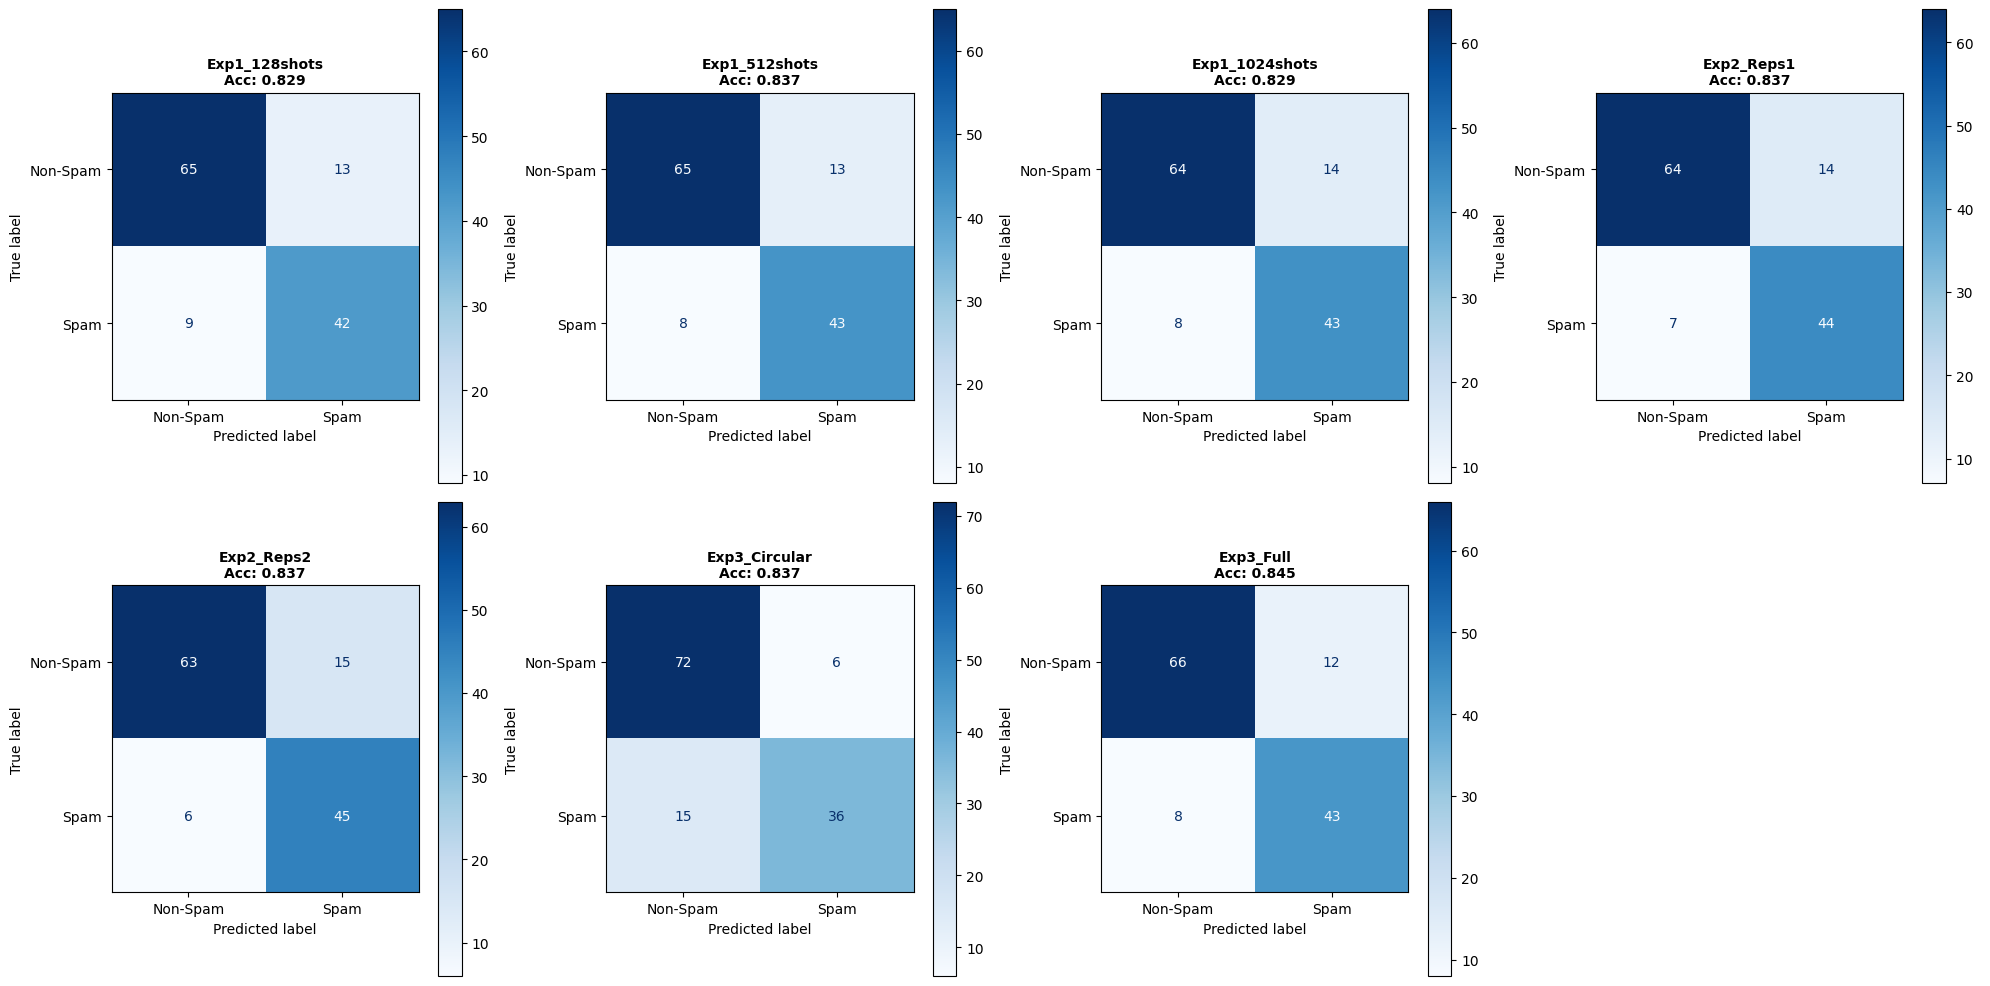

✓ Confusion matrices saved: confusion_matrices_all_experiments.png


In [19]:
# ===================================================================
# CONFUSION MATRICES FOR EACH EXPERIMENT
# ===================================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

print("\nGenerating confusion matrices for all experiments...")

fig_rows = (len(experiments) + 3) // 4  # Calculate rows needed (4 plots per row)
fig, axes = plt.subplots(fig_rows, 4, figsize=(20, 5 * fig_rows))
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for idx, result in enumerate(all_results):
    y_test = np.array(result['y_test'])
    y_pred = np.array(result['y_pred'])
    
    # Create confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Spam', 'Spam'])
    
    # Plot on corresponding subplot
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d')
    axes[idx].set_title(f"{result['experiment_id']}\nAcc: {result['test_acc']:.3f}", 
                        fontsize=10, fontweight='bold')
    axes[idx].grid(False)

# Hide unused subplots
for idx in range(len(all_results), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('confusion_matrices_all_experiments.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Confusion matrices saved: confusion_matrices_all_experiments.png")


In [20]:
# ===================================================================
# BEST CONFIGURATIONS ANALYSIS
# ===================================================================

print("\n" + "=" * 80)
print("BEST CONFIGURATIONS ANALYSIS")
print("=" * 80)


# ==========================================
# 1. BEST TEST ACCURACY
# ==========================================
best_acc_idx = results_df['test_acc'].idxmax()
best_acc = results_df.iloc[best_acc_idx]

print("\n" + "─" * 80)
print("1️BEST TEST ACCURACY (Primary Target)")
print("─" * 80)
print(f"\nExperiment ID: {best_acc['experiment_id']}")
print(f"  → Test Accuracy: {best_acc['test_acc']:.4f}")
print(f"  → Test Balanced Acc: {best_acc['test_balanced_acc']:.4f}")
print(f"  → Precision: {best_acc['precision']:.4f}")
print(f"  → Recall: {best_acc['spam_recall']:.4f}")
print(f"  → F1-Score: {best_acc['f1_score']:.4f}")
print(f"  → Precision: {best_acc['precision']:.4f}")
print(f"  → Recall: {best_acc['spam_recall']:.4f}")
print(f"  → F1-Score: {best_acc['f1_score']:.4f}")
print(f"  → Generalization Gap: {best_acc['gen_gap']:.4f}")
print(f"\nConfiguration:")
print(f"  → Samples: {int(best_acc['samples'])}")
print(f"  → Features (k): {int(best_acc['k_features'])}")
print(f"  → Shots: {int(best_acc['shots'])}")
print(f"  → Reps: {int(best_acc['reps'])}")
print(f"  → Entanglement: {best_acc['entanglement']}")
print(f"  → Optimal C: {best_acc['best_c']}")
print(f"\nTiming:")
print(f"  → Kernel Time: {best_acc['kernel_time']:.2f}s")
print(f"  → Training Time: {best_acc['train_time']:.2f}s")


# ==========================================
# 2. BEST SPAM RECALL
# ==========================================
best_recall_idx = results_df['spam_recall'].idxmax()
best_recall = results_df.iloc[best_recall_idx]

print("\n" + "─" * 80)
print("2️BEST SPAM RECALL (Spam Detection Focus)")
print("─" * 80)
print(f"\nExperiment ID: {best_recall['experiment_id']}")
print(f"  → Precision: {best_recall['precision']:.4f}")
print(f"  → Recall: {best_recall['spam_recall']:.4f}")
print(f"  → F1-Score: {best_recall['f1_score']:.4f}")
print(f"  → Test Accuracy: {best_recall['test_acc']:.4f}")
print(f"  → Test Balanced Acc: {best_recall['test_balanced_acc']:.4f}")
print(f"  → Generalization Gap: {best_recall['gen_gap']:.4f}")
print(f"\nConfiguration:")
print(f"  → Samples: {int(best_recall['samples'])}")
print(f"  → Features (k): {int(best_recall['k_features'])}")
print(f"  → Shots: {int(best_recall['shots'])}")
print(f"  → Reps: {int(best_recall['reps'])}")
print(f"  → Entanglement: {best_recall['entanglement']}")
print(f"  → Optimal C: {best_recall['best_c']}")


# ==========================================
# 3. BEST GENERALIZATION
# ==========================================
best_gen_idx = results_df['gen_gap'].idxmin()
best_gen = results_df.iloc[best_gen_idx]

print("\n" + "─" * 80)
print("BEST GENERALIZATION (Lowest Overfitting)")
print("─" * 80)
print(f"\nExperiment ID: {best_gen['experiment_id']}")
print(f"  → Generalization Gap: {best_gen['gen_gap']:.4f}")
print(f"  → Test Accuracy: {best_gen['test_acc']:.4f}")
print(f"  → Precision: {best_gen['precision']:.4f}")
print(f"  → Recall: {best_gen['spam_recall']:.4f}")
print(f"  → F1-Score: {best_gen['f1_score']:.4f}")
print(f"\nConfiguration:")
print(f"  → Samples: {int(best_gen['samples'])}")
print(f"  → Features (k): {int(best_gen['k_features'])}")
print(f"  → Shots: {int(best_gen['shots'])}")
print(f"  → Reps: {int(best_gen['reps'])}")
print(f"  → Entanglement: {best_gen['entanglement']}")


# ==========================================
# 4. BEST CROSS-VALIDATION SCORE
# ==========================================
best_cv_idx = results_df['cv_score'].idxmax()
best_cv = results_df.iloc[best_cv_idx]

print("\n" + "─" * 80)
print("BEST CROSS-VALIDATION SCORE (Training Reliability)")
print("─" * 80)
print(f"\nExperiment ID: {best_cv['experiment_id']}")
print(f"  → CV Score: {best_cv['cv_score']:.4f}")
print(f"  → Test Accuracy: {best_cv['test_acc']:.4f}")
print(f"  → Precision: {best_cv['precision']:.4f}")
print(f"  → Recall: {best_cv['spam_recall']:.4f}")
print(f"  → F1-Score: {best_cv['f1_score']:.4f}")
print(f"  → Generalization Gap: {best_cv['gen_gap']:.4f}")
print(f"\nConfiguration:")
print(f"  → Samples: {int(best_cv['samples'])}")
print(f"  → Features (k): {int(best_cv['k_features'])}")
print(f"  → Shots: {int(best_cv['shots'])}")
print(f"  → Reps: {int(best_cv['reps'])}")
print(f"  → Entanglement: {best_cv['entanglement']}")


# ==========================================
# 5. FASTEST COMPUTATION
# ==========================================
fastest_idx = results_df['kernel_time'].idxmin()
fastest = results_df.iloc[fastest_idx]

print("\n" + "─" * 80)
print("FASTEST COMPUTATION (Efficiency)")
print("─" * 80)
print(f"\nExperiment ID: {fastest['experiment_id']}")
print(f"  → Kernel Time: {fastest['kernel_time']:.2f}s")
print(f"  → Test Accuracy: {fastest['test_acc']:.4f}")
print(f"  → Precision: {fastest['precision']:.4f}")
print(f"  → Recall: {fastest['spam_recall']:.4f}")
print(f"  → F1-Score: {fastest['f1_score']:.4f}")
print(f"\nConfiguration:")
print(f"  → Samples: {int(fastest['samples'])}")
print(f"  → Features (k): {int(fastest['k_features'])}")
print(f"  → Shots: {int(fastest['shots'])}")
print(f"  → Reps: {int(fastest['reps'])}")
print(f"  → Entanglement: {fastest['entanglement']}")


# ==========================================
# COMPARISON TABLE
# ==========================================
print("\n" + "=" * 80)
print("COMPARISON OF BEST CONFIGURATIONS")
print("=" * 80)

comparison_data = {
    'Category': ['Best Accuracy', 'Best Recall', 'Best Generalization', 'Best CV', 'Fastest'],
    'Exp ID': [
        best_acc['experiment_id'],
        best_recall['experiment_id'],
        best_gen['experiment_id'],
        best_cv['experiment_id'],
        fastest['experiment_id']
    ],
    'Test Acc': [
        f"{best_acc['test_acc']:.4f}",
        f"{best_recall['test_acc']:.4f}",
        f"{best_gen['test_acc']:.4f}",
        f"{best_cv['test_acc']:.4f}",
        f"{fastest['test_acc']:.4f}"
    ],
    'Precision': [
        f"{best_acc['precision']:.4f}",
        f"{best_recall['precision']:.4f}",
        f"{best_gen['precision']:.4f}",
        f"{best_cv['precision']:.4f}",
        f"{fastest['precision']:.4f}"
    ],
    'F1-Score': [
        f"{best_acc['f1_score']:.4f}",
        f"{best_recall['f1_score']:.4f}",
        f"{best_gen['f1_score']:.4f}",
        f"{best_cv['f1_score']:.4f}",
        f"{fastest['f1_score']:.4f}"
    ],
    'Spam Recall': [
        f"{best_acc['spam_recall']:.4f}",
        f"{best_recall['spam_recall']:.4f}",
        f"{best_gen['spam_recall']:.4f}",
        f"{best_cv['spam_recall']:.4f}",
        f"{fastest['spam_recall']:.4f}"
    ],
    'Gen Gap': [
        f"{best_acc['gen_gap']:.4f}",
        f"{best_recall['gen_gap']:.4f}",
        f"{best_gen['gen_gap']:.4f}",
        f"{best_cv['gen_gap']:.4f}",
        f"{fastest['gen_gap']:.4f}"
    ],
    'Shots': [
        int(best_acc['shots']),
        int(best_recall['shots']),
        int(best_gen['shots']),
        int(best_cv['shots']),
        int(fastest['shots'])
    ],
    'Reps': [
        int(best_acc['reps']),
        int(best_recall['reps']),
        int(best_gen['reps']),
        int(best_cv['reps']),
        int(fastest['reps'])
    ],
    'Entangle': [
        best_acc['entanglement'],
        best_recall['entanglement'],
        best_gen['entanglement'],
        best_cv['entanglement'],
        fastest['entanglement']
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))


# ==========================================
# EXPORT CONFIGURATION
# ==========================================
print("\n" + "=" * 80)
print("CONFIGURATION EXPORT")
print("=" * 80)

qsvm_config = {
    'best_accuracy': {
        'experiment_id': best_acc['experiment_id'],
        'test_acc': float(best_acc['test_acc']),
        'spam_recall': float(best_acc['spam_recall']),
        'precision': float(best_acc['precision']),
        'f1_score': float(best_acc['f1_score']),
        'samples': int(best_acc['samples']),
        'k_features': int(best_acc['k_features']),
        'shots': int(best_acc['shots']),
        'reps': int(best_acc['reps']),
        'entanglement': best_acc['entanglement'],
        'optimal_C': float(best_acc['best_c']),
        'kernel_time': float(best_acc['kernel_time'])
    },
    'best_recall': {
        'experiment_id': best_recall['experiment_id'],
        'spam_recall': float(best_recall['spam_recall']),
        'precision': float(best_recall['precision']),
        'f1_score': float(best_recall['f1_score']),
        'test_acc': float(best_recall['test_acc']),
        'samples': int(best_recall['samples']),
        'k_features': int(best_recall['k_features']),
        'shots': int(best_recall['shots']),
        'reps': int(best_recall['reps']),
        'entanglement': best_recall['entanglement']
    },
    'best_generalization': {
        'experiment_id': best_gen['experiment_id'],
        'gen_gap': float(best_gen['gen_gap']),
        'test_acc': float(best_gen['test_acc']),
        'precision': float(best_gen['precision']),
        'f1_score': float(best_gen['f1_score']),
        'samples': int(best_gen['samples']),
        'k_features': int(best_gen['k_features'])
    },
    'fastest_computation': {
        'experiment_id': fastest['experiment_id'],
        'kernel_time': float(fastest['kernel_time']),
        'test_acc': float(fastest['test_acc']),
        'precision': float(fastest['precision']),
        'f1_score': float(fastest['f1_score']),
        'shots': int(fastest['shots']),
        'reps': int(fastest['reps'])
    }
}

# Save configuration
import json
with open('ideal_qsvm_best_configurations.json', 'w') as f:
    json.dump(qsvm_config, f, indent=4)

print("\n✓ Configuration saved to: ideal_qsvm_best_configurations.json")
print("=" * 80)



BEST CONFIGURATIONS ANALYSIS

────────────────────────────────────────────────────────────────────────────────
1️BEST TEST ACCURACY (Primary Target)
────────────────────────────────────────────────────────────────────────────────

Experiment ID: Exp3_Full
  → Test Accuracy: 0.8450
  → Test Balanced Acc: 0.8446
  → Precision: 0.7818
  → Recall: 0.8431
  → F1-Score: 0.8113
  → Precision: 0.7818
  → Recall: 0.8431
  → F1-Score: 0.8113
  → Generalization Gap: 0.0317

Configuration:
  → Samples: 300
  → Features (k): 3
  → Shots: 1024
  → Reps: 1
  → Entanglement: full
  → Optimal C: 1.0

Timing:
  → Kernel Time: 0.00s
  → Training Time: 0.00s

────────────────────────────────────────────────────────────────────────────────
2️BEST SPAM RECALL (Spam Detection Focus)
────────────────────────────────────────────────────────────────────────────────

Experiment ID: Exp2_Reps2
  → Precision: 0.7500
  → Recall: 0.8824
  → F1-Score: 0.8108
  → Test Accuracy: 0.8372
  → Test Balanced Acc: 0.8450
  

QUANTUM SVM VISUALIZATION SUITE

Loaded 7 experiments
Columns: ['experiment_id', 'exp_number', 'samples', 'k_features', 'shots', 'reps', 'entanglement', 'selected_features', 'best_c', 'cv_score', 'train_acc', 'test_acc', 'test_balanced_acc', 'precision', 'spam_recall', 'f1_score', 'gen_gap', 'kernel_time', 'train_time', 'y_test', 'y_pred']

────────────────────────────────────────────────────────────────────────────────
Plotting Exp1: Effect of Number of Shots (Measurements)
────────────────────────────────────────────────────────────────────────────────
Found 3 experiments in this series


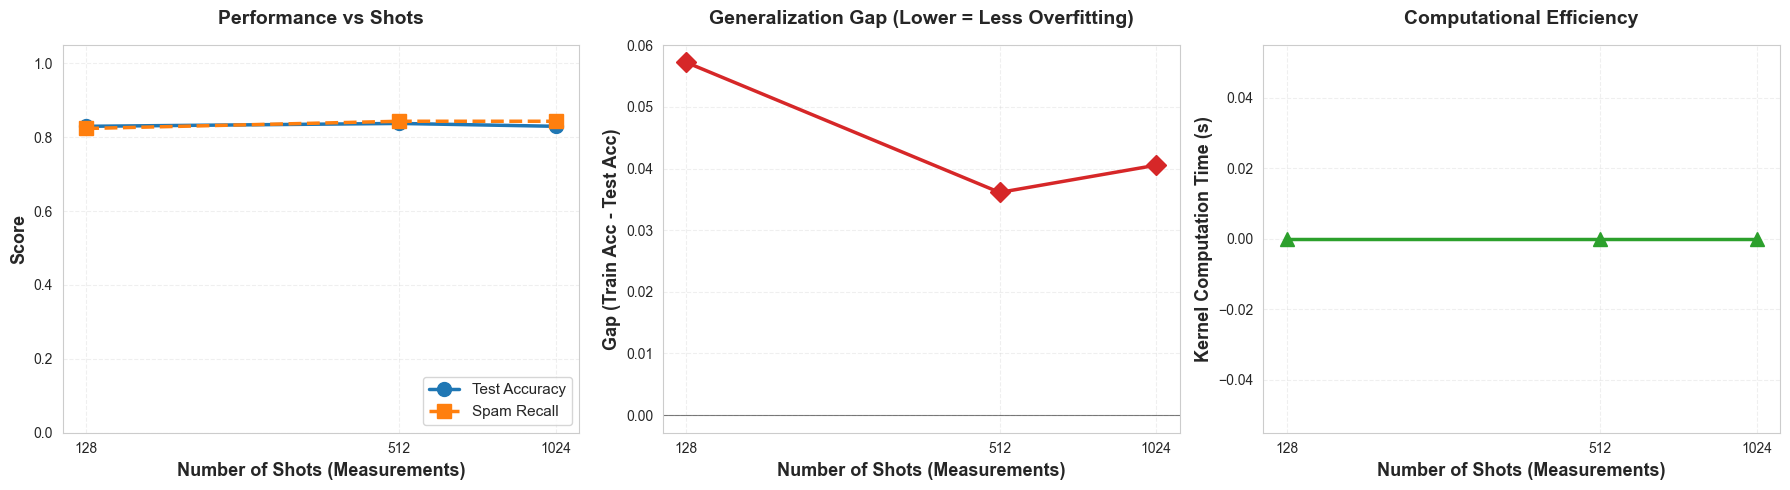

✓ Saved: qsvm_Exp1_analysis.png

────────────────────────────────────────────────────────────────────────────────
Plotting Exp2: Effect of Circuit Depth (Repetitions)
────────────────────────────────────────────────────────────────────────────────
Found 2 experiments in this series


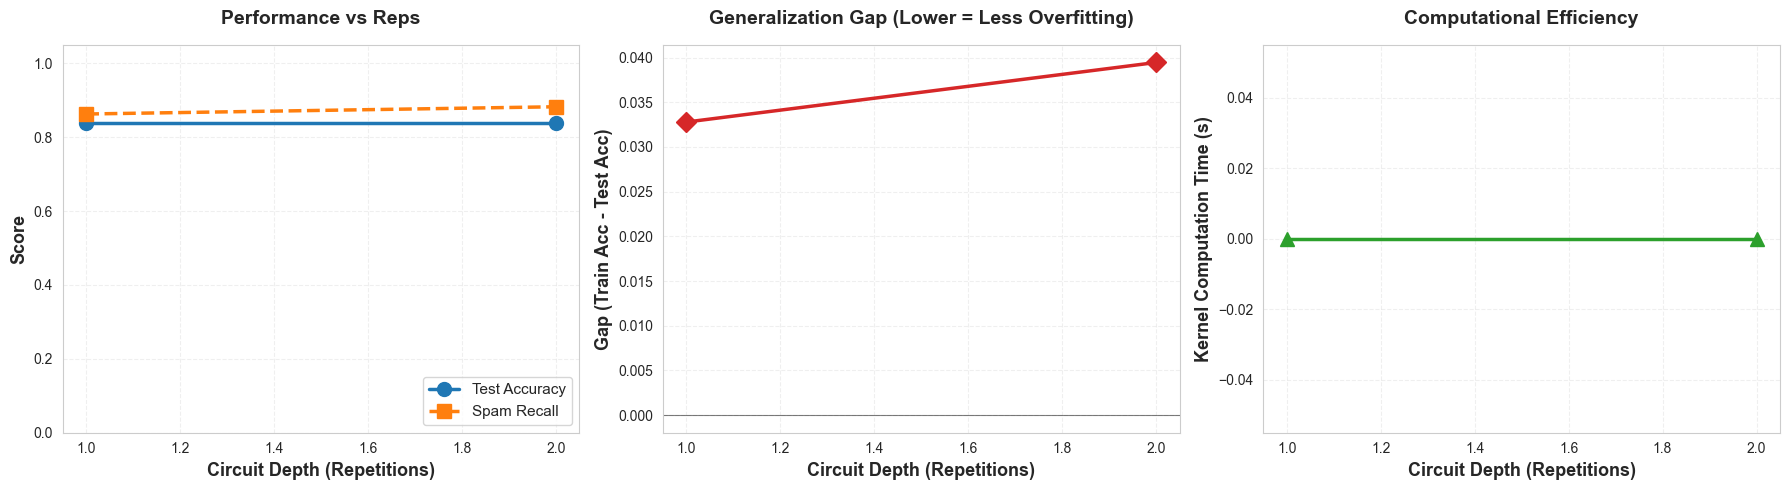

✓ Saved: qsvm_Exp2_analysis.png

────────────────────────────────────────────────────────────────────────────────
Plotting Exp3: Effect of Entanglement Topology
────────────────────────────────────────────────────────────────────────────────
Found 2 experiments in this series


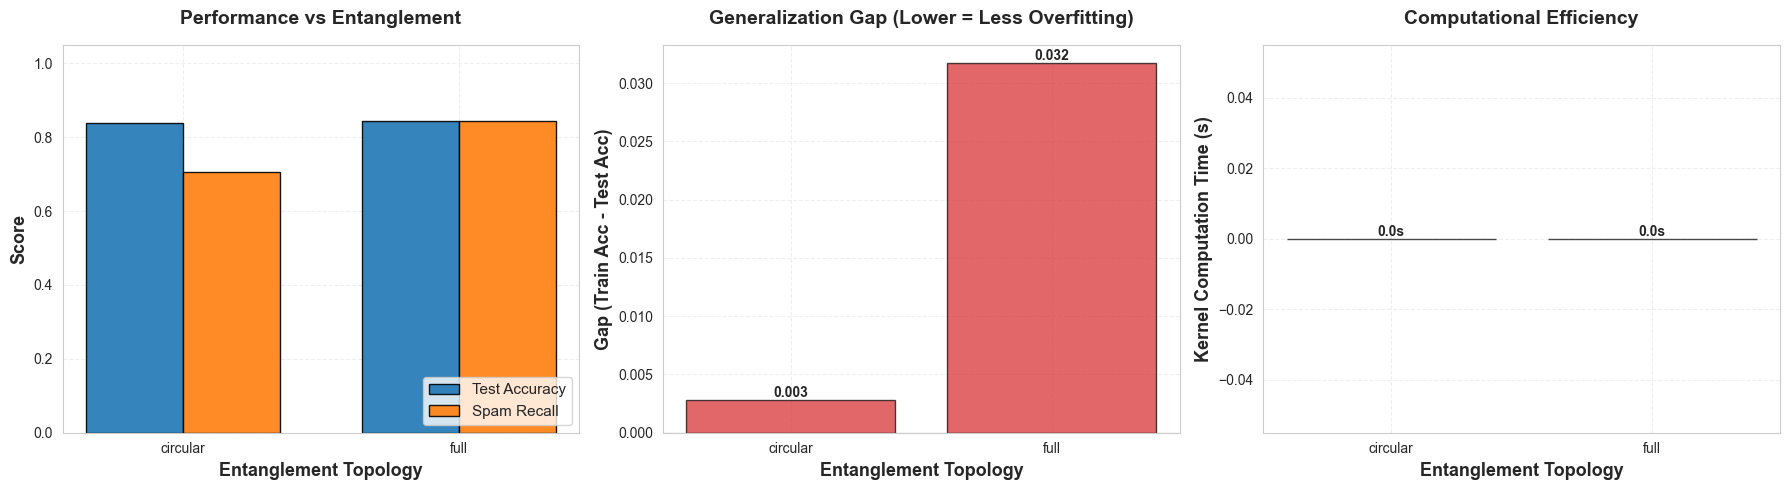

✓ Saved: qsvm_Exp3_analysis.png

GLOBAL PERFORMANCE HEATMAP


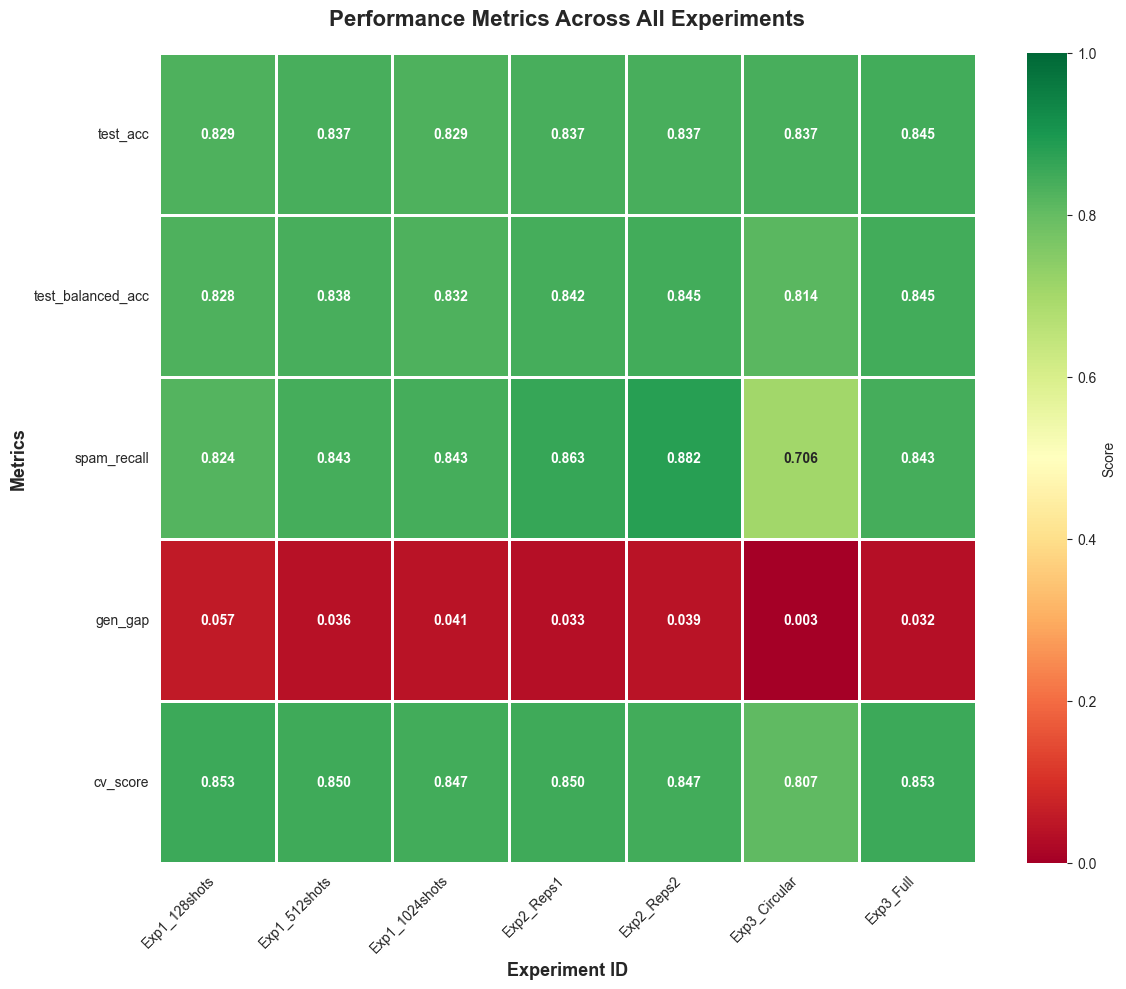

✓ Saved: qsvm_heatmap_summary.png

ALL VISUALIZATIONS COMPLETE

Generated Files:
  1. qsvm_Exp1_analysis.png (Shot Noise Analysis)
  2. qsvm_Exp2_analysis.png (Circuit Depth Analysis)
  3. qsvm_Exp3_analysis.png (Entanglement Comparison)
  4. qsvm_heatmap_summary.png (Global Performance Heatmap)


In [21]:
# ===================================================================
# VISUALIZATION
# ===================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


# ==========================================
# CONFIGURATION & STYLE
# ==========================================
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (18, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 8


def plot_qsvm_experiments(df):
    """
    Generates standardized visualizations for Ideal QSVM experiments.
    Handles: ExpBest, Exp2 (shots), Exp3 (reps), Exp4 (entanglement)
    """
    
    # Map Experiment SERIES to parameters
    exp_map = {
        'Exp1': {
            'param': 'shots',
            'xlabel': 'Number of Shots (Measurements)',
            'log_x': True,
            'type': 'line',
            'filter': 'Exp1'
        },
        'Exp2': {
            'param': 'reps',
            'xlabel': 'Circuit Depth (Repetitions)',
            'log_x': False,
            'type': 'line',
            'filter': 'Exp2'
        },
        'Exp3': {
            'param': 'entanglement',
            'xlabel': 'Entanglement Topology',
            'log_x': False,
            'type': 'bar',
            'filter': 'Exp3'
        }
    }

    
    
    # Iterate through each experiment series
    for group_key, config in exp_map.items():
        # Filter data for this series (e.g., Exp2a, Exp2b, Exp2c OR ExpBest if baseline)
        if group_key == 'Exp2' or group_key == 'Exp3' or group_key == 'Exp4':
            subset = df[df['experiment_id'].str.contains(config['filter'])].copy()
            # Also include ExpBest as baseline if applicable
            baseline = df[df['experiment_id'] == 'ExpBest'].copy()
            if not baseline.empty and config['param'] in ['shots', 'reps']:
                subset = pd.concat([baseline, subset], ignore_index=True)
        else:
            subset = df[df['experiment_id'].str.contains(group_key)].copy()
        
        if subset.empty:
            print(f"⚠️  No data found for {group_key}")
            continue
            
        param = config['param']
        
        # Sort by parameter for line plots
        if config['type'] == 'line':
            subset = subset.sort_values(by=param)
            
        print(f"\n{'─'*80}")
        print(f"Plotting {group_key}: Effect of {config['xlabel']}")
        print(f"{'─'*80}")
        print(f"Found {len(subset)} experiments in this series")
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # -------------------------------------------------------
        # SUBPLOT 1: PERFORMANCE (Accuracy vs Recall)
        # -------------------------------------------------------
        if config['type'] == 'bar':
            x_pos = np.arange(len(subset))
            width = 0.35
            axes[0].bar(x_pos - width/2, subset['test_acc'], width, 
                       label='Test Accuracy', color='#1f77b4', alpha=0.9, edgecolor='black')
            axes[0].bar(x_pos + width/2, subset['spam_recall'], width, 
                       label='Spam Recall', color='#ff7f0e', alpha=0.9, edgecolor='black')
            axes[0].set_xticks(x_pos)
            axes[0].set_xticklabels(subset[param], rotation=0)
        else:
            axes[0].plot(subset[param], subset['test_acc'], 'o-', 
                        label='Test Accuracy', color='#1f77b4', linewidth=2.5, markersize=10)
            axes[0].plot(subset[param], subset['spam_recall'], 's--', 
                        label='Spam Recall', color='#ff7f0e', linewidth=2.5, markersize=10)
            if config['log_x']: 
                axes[0].set_xscale('log', base=2)
                axes[0].set_xticks(subset[param].unique())
                axes[0].set_xticklabels(subset[param].unique())

        axes[0].set_xlabel(config['xlabel'], fontsize=13, fontweight='bold')
        axes[0].set_ylabel('Score', fontsize=13, fontweight='bold')
        axes[0].set_title(f'Performance vs {param.replace("_", " ").title()}', 
                         fontsize=14, fontweight='bold', pad=15)
        axes[0].set_ylim(0, 1.05)
        axes[0].legend(loc='lower right', fontsize=11)
        axes[0].grid(True, alpha=0.3, linestyle='--')


        # -------------------------------------------------------
        # SUBPLOT 2: GENERALIZATION GAP
        # -------------------------------------------------------
        if config['type'] == 'bar':
            bars = axes[1].bar(subset[param], subset['gen_gap'], 
                              color='#d62728', alpha=0.7, edgecolor='black')
            axes[1].set_xticks(range(len(subset)))
            axes[1].set_xticklabels(subset[param], rotation=0)
            
            # Add value labels on bars
            for bar in bars:
                height = bar.get_height()
                axes[1].text(bar.get_x() + bar.get_width()/2., height,
                           f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        else:
            axes[1].plot(subset[param], subset['gen_gap'], 'D-', 
                        color='#d62728', linewidth=2.5, markersize=10)
            if config['log_x']: 
                axes[1].set_xscale('log', base=2)
                axes[1].set_xticks(subset[param].unique())
                axes[1].set_xticklabels(subset[param].unique())
            
        axes[1].set_xlabel(config['xlabel'], fontsize=13, fontweight='bold')
        axes[1].set_ylabel('Gap (Train Acc - Test Acc)', fontsize=13, fontweight='bold')
        axes[1].set_title('Generalization Gap (Lower = Less Overfitting)', 
                         fontsize=14, fontweight='bold', pad=15)
        axes[1].grid(True, alpha=0.3, linestyle='--')
        axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)


        # -------------------------------------------------------
        # SUBPLOT 3: COMPUTATIONAL COST
        # -------------------------------------------------------
        if config['type'] == 'bar':
            bars = axes[2].bar(subset[param], subset['kernel_time'], 
                              color='#2ca02c', alpha=0.7, edgecolor='black')
            axes[2].set_xticks(range(len(subset)))
            axes[2].set_xticklabels(subset[param], rotation=0)
            
            # Add time labels
            for bar in bars:
                height = bar.get_height()
                axes[2].text(bar.get_x() + bar.get_width()/2., height,
                           f'{height:.1f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')
        else:
            axes[2].plot(subset[param], subset['kernel_time'], '^-', 
                        color='#2ca02c', linewidth=2.5, markersize=10)
            if config['log_x']: 
                axes[2].set_xscale('log', base=2)
                axes[2].set_xticks(subset[param].unique())
                axes[2].set_xticklabels(subset[param].unique())

        axes[2].set_xlabel(config['xlabel'], fontsize=13, fontweight='bold')
        axes[2].set_ylabel('Kernel Computation Time (s)', fontsize=13, fontweight='bold')
        axes[2].set_title('Computational Efficiency', fontsize=14, fontweight='bold', pad=15)
        axes[2].grid(True, alpha=0.3, linestyle='--')
        
        plt.tight_layout()
        plt.savefig(f'qsvm_{group_key}_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✓ Saved: qsvm_{group_key}_analysis.png")


    # -------------------------------------------------------
    # SUMMARY HEATMAP
    # -------------------------------------------------------
    print(f"\n{'='*80}")
    print("GLOBAL PERFORMANCE HEATMAP")
    print(f"{'='*80}")
    
    plt.figure(figsize=(12, 10))
    
    # Metrics to display
    metrics = ['test_acc', 'test_balanced_acc', 'spam_recall', 'gen_gap', 'cv_score']
    
    # Prepare data
    heatmap_data = df.set_index('experiment_id')[metrics].T
    
    # Plot
    sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn', 
                vmin=0, vmax=1, linewidths=1, linecolor='white',
                cbar_kws={'label': 'Score'}, 
                annot_kws={'fontsize': 10, 'fontweight': 'bold'})
    
    plt.title('Performance Metrics Across All Experiments', 
             fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Experiment ID', fontsize=13, fontweight='bold')
    plt.ylabel('Metrics', fontsize=13, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('qsvm_heatmap_summary.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: qsvm_heatmap_summary.png")

try:
    # Load results if not already in memory
    if 'results_df' not in locals():
        results_df = pd.read_csv('qsvm_selectkbest_all_experiments.csv')
    
    print("="*80)
    print("QUANTUM SVM VISUALIZATION SUITE")
    print("="*80)
    print(f"\nLoaded {len(results_df)} experiments")
    print(f"Columns: {list(results_df.columns)}")
    
    # Run visualizations
    plot_qsvm_experiments(results_df)
    
    print("\n" + "="*80)
    print("ALL VISUALIZATIONS COMPLETE")
    print("="*80)
    print("\nGenerated Files:")
    print("  1. qsvm_Exp1_analysis.png (Shot Noise Analysis)")
    print("  2. qsvm_Exp2_analysis.png (Circuit Depth Analysis)")
    print("  3. qsvm_Exp3_analysis.png (Entanglement Comparison)")
    print("  4. qsvm_heatmap_summary.png (Global Performance Heatmap)")

    
except FileNotFoundError:
    print("Error: 'qsvm_selectkbest_all_experiments.csv' not found")
    print("   Make sure you've run the main experiment loop first!")
except Exception as e:
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()


In [ ]:
# ===================================================================
# GENERATE SUMMARY TABLE
# ===================================================================
import pandas as pd

# Load results
try:
    if 'results_df' not in locals():
        results_df = pd.read_csv('qsvm_selectkbest_all_experiments.csv')
    
    print("\n" + "="*100)
    print("Table 6.4 : Spambase Results - All Ideal QSVM Experiments")
    print("="*100)

    # Define columns to show
    col_map = {
        'experiment_id': 'Experiment ID',
        'shots': 'Shots',
        'reps': 'Reps',
        'entanglement': 'Entanglement',
        'train_acc': 'Train Acc (%)',
        'test_acc': 'Test Acc (%)',
        'precision': 'Precision (%)',
        'spam_recall': 'Spam Recall (%)',
        'f1_score': 'F1 Score (%)',
        'gen_gap': 'Gen Gap (%)',
        'kernel_time': 'Kernel Time (s)'
    }

    # Handle potentially missing columns (backward compatibility)
    available_cols = [c for c in col_map.keys() if c in results_df.columns]
    
    # Create display dataframe
    display_df = results_df[available_cols].copy()
    
    # Rename columns
    display_df.columns = [col_map[c] for c in display_df.columns]
    
    # Format percentages
    pct_cols = ['Train Acc (%)', 'Test Acc (%)', 'Precision (%)', 'Spam Recall (%)', 'F1 Score (%)', 'Gen Gap (%)']
    for col in pct_cols:
        if col in display_df.columns:
            display_df[col] = display_df[col].apply(lambda x: f"{x*100:.2f}%" if isinstance(x, (int, float)) else x)
            
    # Format Time
    if 'Kernel Time (s)' in display_df.columns:
            display_df['Kernel Time (s)'] = display_df['Kernel Time (s)'].apply(lambda x: f"{x:.5f}" if isinstance(x, (int, float)) else x)

    # Display table (Markdown format for easy copying)
    print(display_df.to_markdown(index=False))
    
except Exception as e:
    print(f"Could not generate summary table: {e}")
